In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Carga de datos
df_crypto = pd.read_csv("../data/clean/criptoradar_crypto_final_clean.csv")

In [16]:
# INGENIERÍA DE FEATURES RAPIDA PARA EL ANÁLISIS
# Volatilidad porcentual relativa: (High - Low) / Open
df_crypto['daily_volatility_pct'] = (df_crypto['high'] - df_crypto['low']) / df_crypto['open'] * 100

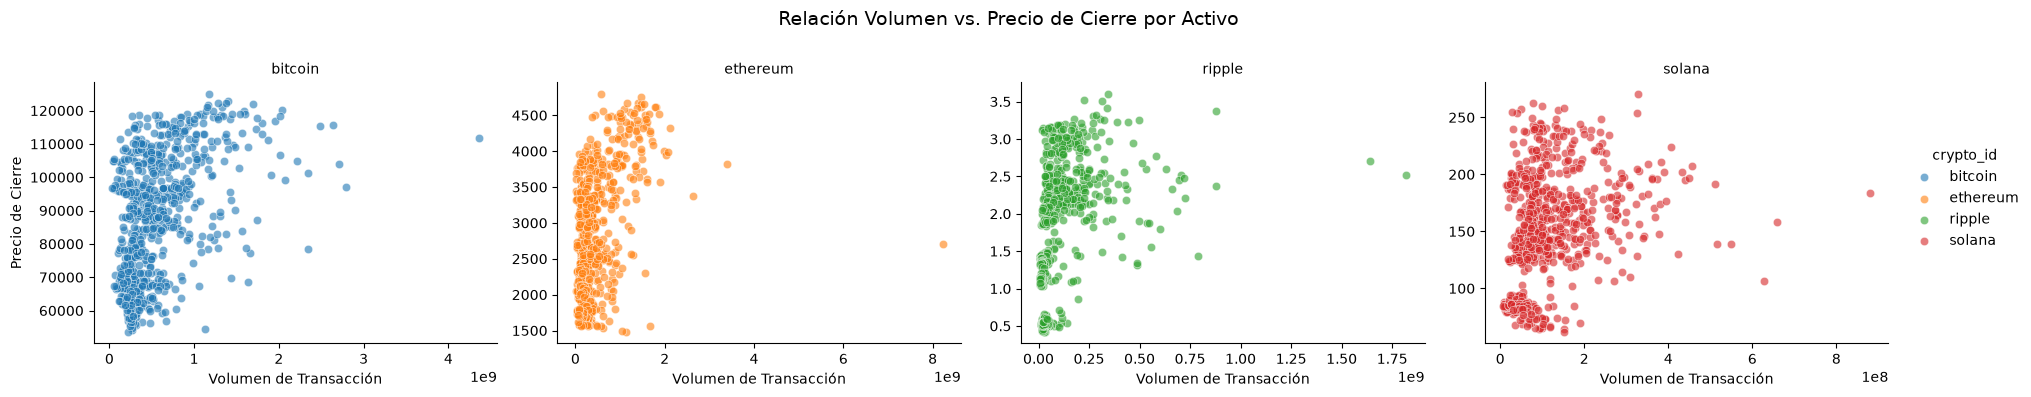

In [17]:
# 1. Numérica vs Numérica: Volumen vs. Cierre por Cripto
# =========================================================================
g = sns.FacetGrid(df_crypto, col="crypto_id", hue="crypto_id", sharey=False, sharex=False, height=4, aspect=1.2)
g.map(sns.scatterplot, "volume", "close", alpha=0.6)
g.add_legend()
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Volumen de Transacción", "Precio de Cierre")
plt.subplots_adjust(top=0.8)
g.fig.suptitle('Relación Volumen vs. Precio de Cierre por Activo', fontsize=14)
plt.show()

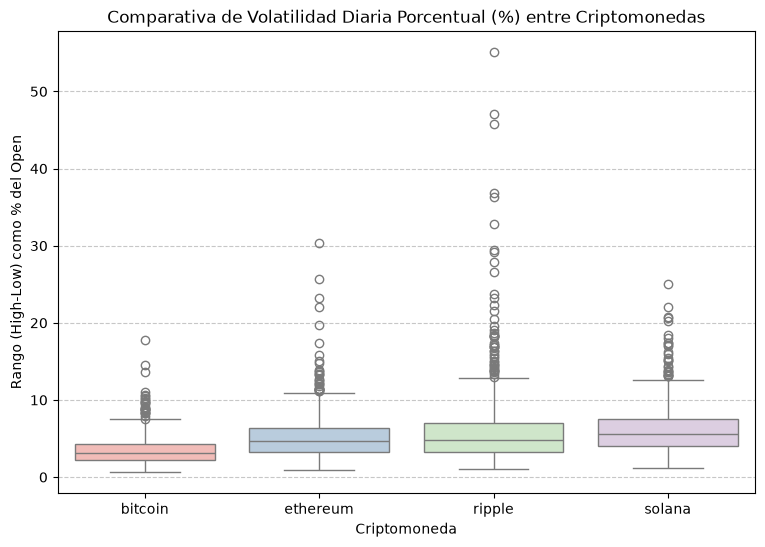

In [18]:
# 2. Categórica vs Numérica: Boxplot de Volatilidad Relativa
# =========================================================================
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_crypto, x='crypto_id', y='daily_volatility_pct', palette='Pastel1',hue='crypto_id')
plt.title('Comparativa de Volatilidad Diaria Porcentual (%) entre Criptomonedas')
plt.xlabel('Criptomoneda')
plt.ylabel('Rango (High-Low) como % del Open')
plt.grid(axis='y', ls='--', alpha=0.7)
plt.show()

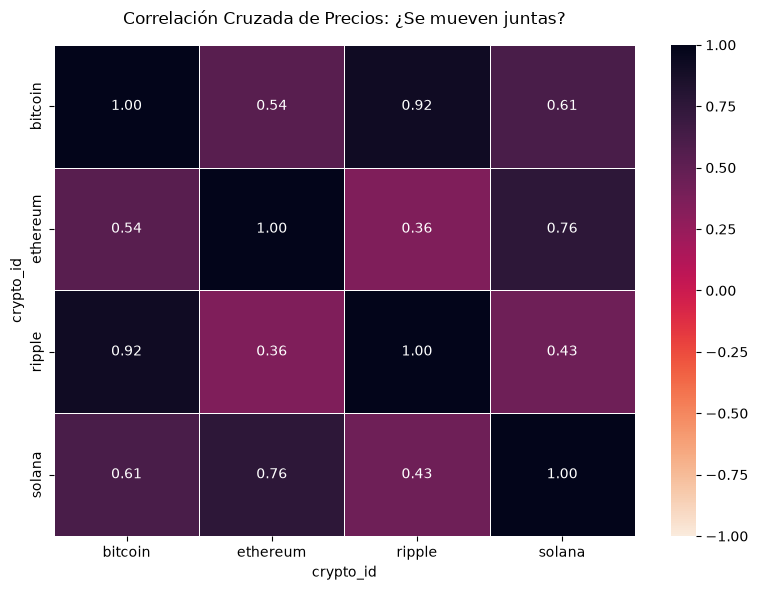

In [19]:
# 3. Correlación Cruzada entre Precios (Pivot Table)
# =========================================================================
# Pivotamos el DataFrame para que cada fila sea una fecha y cada columna el precio 'close' de una cripto
df_pivot = df_crypto.pivot(index='datetime', columns='crypto_id', values='close').dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(df_pivot.corr(method='pearson'), annot=True, cmap='rocket_r', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlación Cruzada de Precios: ¿Se mueven juntas?', fontsize=12, pad=15)
plt.tight_layout()
plt.show()